### Human In the Loop
Review
For human-in-the-loop, we often want to see our graph outputs as its running.

We laid the foundations for this with streaming.

Goals
Now, let's talk about the motivations for human-in-the-loop:

(1) Approval - We can interrupt our agent, surface state to a user, and allow the user to accept an action

(2) Debugging - We can rewind the graph to reproduce or avoid issues

(3) Editing - You can modify the state

LangGraph offers several ways to get or update agent state to support various human-in-the-loop workflows.

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

## Initialize my LLM model
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

In [2]:
### Custom tools
def multiply(a: int, b:int) -> int:
    """Multiply a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b:int) -> float:
    """Divide a by b
    
    Args:
        a: first int
        b: second int
    """
    return a/b

tools = [add, multiply, divide]

In [3]:
## Integrate tools with LLM
llm_with_tools = llm_groq.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x11c2cc590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11c2cd2b0>, model_name='meta-llama/llama-4-scout-17b-16e-instruct', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds a and b.', 'parameters': {'properties': {'a': {'description': 'first int', 'type': 'integer'}, 'b': {'description': 'second int', 'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b.', 'parameters': {'properties': {'a': {'description': 'first int', 't

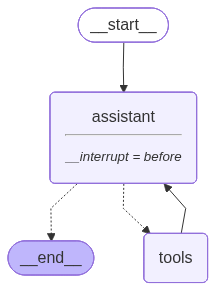

In [4]:
## Workflow with LangGraph
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

## System Message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing aritmetic on a set of inputs.")

## Node definition
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state['messages'])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define the edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
        "assistant",
        # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
        # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to to END
        tools_condition)
builder.add_edge("tools", "assistant")

memory = MemorySaver()

# Human in the loop
graph = builder.compile(interrupt_before=["assistant"],checkpointer=memory)

# Show
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
thread = {"configurable": {"thread_id": "123"}}
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

In [6]:

for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [7]:
state = graph.get_state(thread)
state.next

('assistant',)

In [8]:
# Checkpoint
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='23a9605b-17ef-45e8-a8e5-fd1b41a671f0')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f13d4a7-4ab1-68fc-8000-fd8005563887'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-21T06:22:21.944030+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f13d4a7-4aaf-6c50-bfff-899e0a0317b2'}}, tasks=(PregelTask(id='92135f6b-77c8-cc36-1a6b-cc4614775ae5', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

![Captura de pantalla 2026-04-21 a la(s) 12.27.13 a.m..png](<attachment:Captura de pantalla 2026-04-21 a la(s) 12.27.13 a.m..png>)
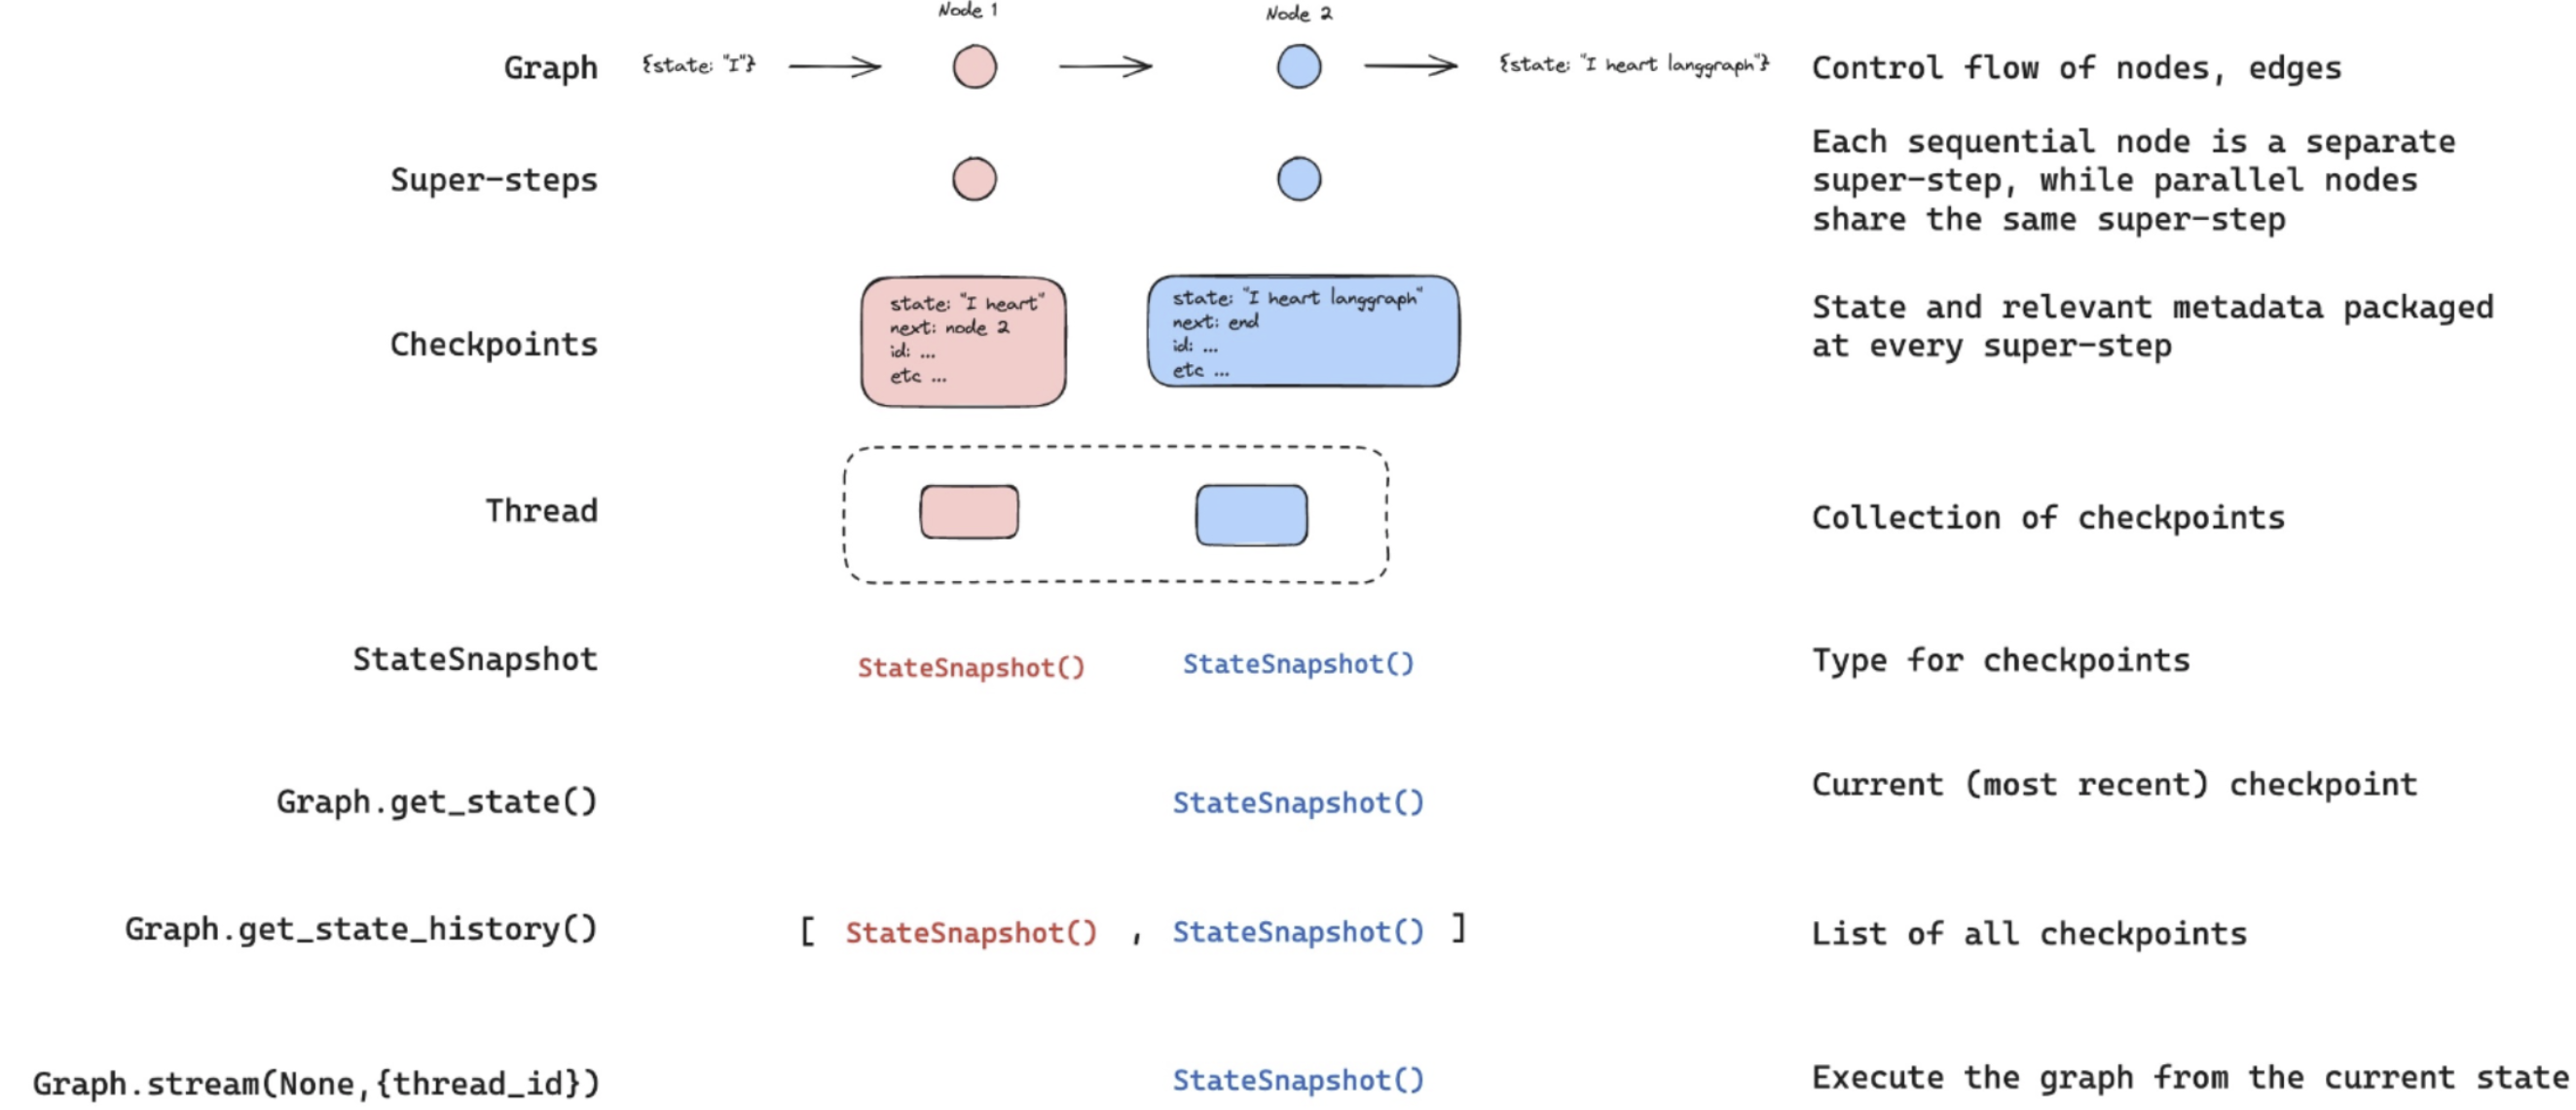

In [ ]:
# Get the list of all checkpoints
graph.get_state_history(thread)

<generator object Pregel.get_state_history at 0x11d2fa820>

In [ ]:
# Continue the execution to Assistant
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (jazr9hqmq)
 Call ID: jazr9hqmq
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [13]:
state = graph.get_state(thread)
state.next

('assistant',)

In [ ]:
# Continue the execution of Assistant and then end
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


### Edit Human Feedback

()